<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day4/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Prédiction du cours des actions avec LSTM

L'entraînement s'exécutera sur : cpu

--- Étape 1 & 2 : Préparation des données boursières ---

--- Étape 3 : Structuration des tenseurs et création des DataLoaders ---
Nombre de lots d'entraînement : 25

--- Étape 4 : Définition de la classe du modèle Hybride ---

--- Étape 5 : Lancement de la boucle d'entraînement ---
Époque 01/20 | Train Loss: 0.020059 | Val Loss: 0.012731
Époque 05/20 | Train Loss: 0.002617 | Val Loss: 0.004694
Époque 10/20 | Train Loss: 0.001023 | Val Loss: 0.002241
Époque 15/20 | Train Loss: 0.001819 | Val Loss: 0.001554
Époque 20/20 | Train Loss: 0.001178 | Val Loss: 0.001059


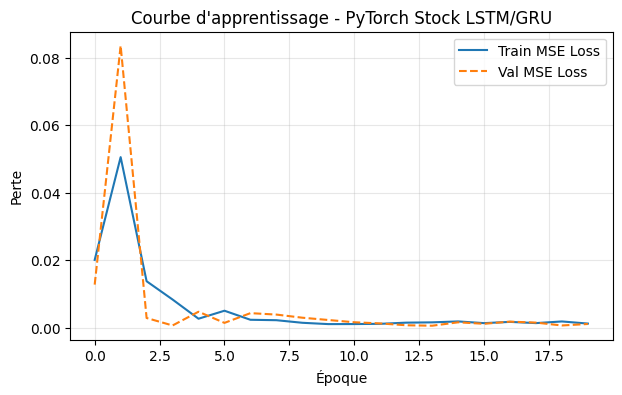


--- Étape 6 : Évaluation sur l'ensemble de test ---
🏆 Score R² d'évaluation finale sur le jeu de test : -3.4569


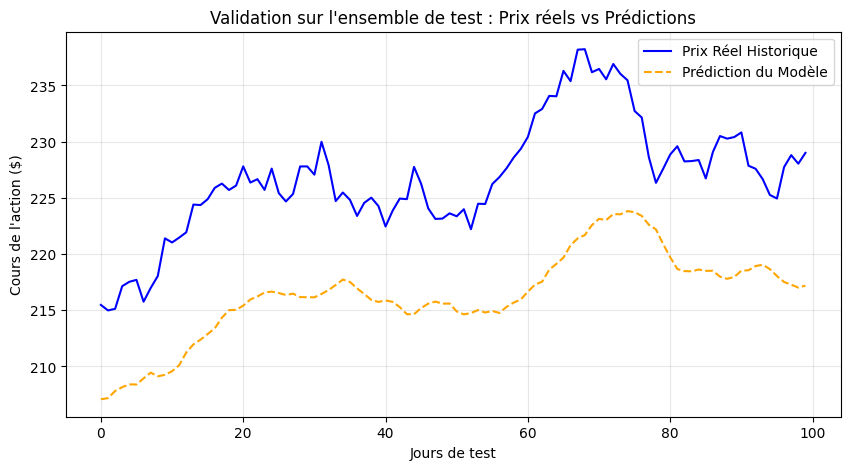


🎉 Félicitations ! Fichier de modèle PyTorch exporté avec succès sous le nom : 'stock_lstm_model.pth'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Fixer les graines aléatoires pour la reproductibilité
np.random.seed(42)
torch.manual_seed(42)

# Détection automatique du GPU si disponible dans Google Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"L'entraînement s'exécutera sur : {device}")

# =====================================================================
# 1 & 2. CHARGEMENT, SIMULATION ET PRÉTRAITEMENT DU JEU DE DONNÉES
# =====================================================================
print("\n--- Étape 1 & 2 : Préparation des données boursières ---")

# Génération de données boursières synthétiques sur 1000 jours (cours réalistes)
date_range = pd.date_range(start="2020-01-01", periods=1000, freq='D')
base_price = 100.0 + np.cumsum(np.random.normal(0.1, 1.5, size=1000))

df = pd.DataFrame({
    'Open': base_price + np.random.normal(0, 0.5, 1000),
    'High': base_price + np.random.uniform(0.5, 2.0, 1000),
    'Low': base_price - np.random.uniform(0.5, 2.0, 1000),
    'Close': base_price,
    'Volume': np.random.randint(10000, 500000, 1000),
    'Unused_Col': np.random.rand(1000) # Colonne inutile à supprimer
}, index=date_range)

# Supprimer les colonnes inutiles
df = df.drop(columns=['Unused_Col'])

# Création de la colonne cible : cours de clôture du lendemain (J+1)
df['Target'] = df['Close'].shift(-1)

# Supprimer la dernière ligne qui possède un Target NaN en raison du shift
df = df.dropna()

# Séparation des caractéristiques (X) et de la cible (y)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
X_raw = df[feature_cols].values
y_raw = df['Target'].values.reshape(-1, 1)

# Normalisation des données à l'aide de MinMaxScaler (indispensable pour les fonctions de portes)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# =====================================================================
# 3. PRÉPARATION DES SÉQUENCES ET PYTORCH DATASET/DATALOADER
# =====================================================================
print("\n--- Étape 3 : Structuration des tenseurs et création des DataLoaders ---")

# Fonction de découpage en fenêtres glissantes (lookback window)
def create_sequences(features, targets, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(features) - seq_length):
        X_seq.append(features[i:(i + seq_length)])
        y_seq.append(targets[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

SEQ_LENGTH = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length=SEQ_LENGTH)

# Division chronologique stricte (80% Train, 10% Validation, 10% Test)
train_size = int(len(X_seq) * 0.8)
val_size = int(len(X_seq) * 0.1)

X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test, y_test = X_seq[train_size+val_size:], y_seq[train_size+val_size:]

# Classe personnalisée PyTorch Dataset
class StockDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Conversion des tableaux numpy en tenseurs de type float32 pour PyTorch
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciation des Datasets
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

# Création des DataLoaders itérables
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Nombre de lots d'entraînement : {len(train_loader)}")

# =====================================================================
# 4. DÉFINITION DE L'ARCHITECTURE DU MODÈLE (LSTM + GRU + DROPOUT)
# =====================================================================
print("\n--- Étape 4 : Définition de la classe du modèle Hybride ---")

class StockPredictionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(StockPredictionModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Première couche récurrente : LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Deuxième couche récurrente : GRU (comme demandé à l'étape 4)
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True)

        # Régularisation par abandon (Dropout)
        self.dropout = nn.Dropout(0.2)

        # Couche dense finale linéaire pour la régression
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Passage dans la cellule LSTM
        lstm_out, _ = self.lstm(x)

        # Passage dans la cellule GRU (reçoit les états de sortie du LSTM)
        gru_out, _ = self.gru(lstm_out)

        # Extraction du dernier pas temporel de la séquence
        last_time_step = gru_out[:, -1, :]

        # Application du dropout et projection linéaire
        out = self.dropout(last_time_step)
        out = self.linear(out)
        return out

# Initialisation du modèle
INPUT_SIZE = len(feature_cols) # 5 caractéristiques
HIDDEN_SIZE = 64
model = StockPredictionModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE).to(device)

# =====================================================================
# 5. ENTRAÎNEMENT DU MODÈLE PYTORCH
# =====================================================================
print("\n--- Étape 5 : Lancement de la boucle d'entraînement ---")

criterion = nn.MSELoss() # Perte d'erreur quadratique moyenne
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Réinitialisation des gradients
        optimizer.zero_grad()

        # Passe avant (Forward)
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Rétropropagation (Backward) et mise à jour des poids
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Phase d'évaluation sur le jeu de validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Époque {epoch+1:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

# Tracé des courbes de perte
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train MSE Loss')
plt.plot(val_losses, label='Val MSE Loss', linestyle='--')
plt.title("Courbe d'apprentissage - PyTorch Stock LSTM/GRU")
plt.xlabel("Époque")
plt.ylabel("Perte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =====================================================================
# 6. ÉVALUATION FINALE ET SCORE R²
# =====================================================================
print("\n--- Étape 6 : Évaluation sur l'ensemble de test ---")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Inversion de la normalisation pour évaluer sur les vraies valeurs boursières
true_prices = scaler_y.inverse_transform(all_targets)
predicted_prices = scaler_y.inverse_transform(all_preds)

# Calcul du coefficient de détermination R²
r2 = r2_score(true_prices, predicted_prices)

print("="*60)
print(f"🏆 Score R² d'évaluation finale sur le jeu de test : {r2:.4f}")
print("="*60)

# Visualisation finale des cours réels vs prédictions
plt.figure(figsize=(10, 5))
plt.plot(true_prices, label="Prix Réel Historique", color='blue')
plt.plot(predicted_prices, label="Prédiction du Modèle", color='orange', linestyle='--')
plt.title("Validation sur l'ensemble de test : Prix réels vs Prédictions")
plt.xlabel("Jours de test")
plt.ylabel("Cours de l'action ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Sauvegarde de l'artefact du modèle entraîné corrigée avec state_dict()
torch.save(model.state_dict(), 'stock_lstm_model.pth')
print("\n🎉 Félicitations ! Fichier de modèle PyTorch exporté avec succès sous le nom : 'stock_lstm_model.pth'")
